# EDA - Prestacao de contas eleitorais 2026 (Polars)

**Fonte:** repositorio de dados eleitorais do TSE - `data/prestacao_de_contas_eleitorais_candidatos_2026/`.

**Contexto:** Eleicoes Gerais Estaduais 2026 (eleicao de 04/10/2026). Cargos: Presidente, Governador, Senador, Deputado Federal, Estadual e Distrital. Os arquivos `*_BRASIL.csv` ja sao a consolidacao das 28 UFs e por isso sao a unica base usada aqui (os arquivos por UF seriam duplicacao).

**Ressalva central:** o snapshot foi gerado em 27/09/2026, antes da eleicao, e so contem entregas do tipo `Parcial` e `Relatorio Financeiro` - **nao ha prestacao `Final`**. Logo, todos os totais sao preliminares e tendem a crescer.

**Stack:** leitura/limpeza em [Polars](https://pola.rs) via pacote `candidatos.model.loader` (Latin-1, separador `;`, decimal com virgula, sentinelas `#NULO=-1`, `#NE=-3`, `-4`). O Polars mantem as quatro tabelas em ~0,4 GB (contra ~2,2 GB do pandas).

In [1]:
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path.cwd() / "src"))

import importlib

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from candidatos.model import loader as tse

importlib.reload(tse)  # recarrega o modulo caso o kernel ja estivesse ativo

pl.Config.set_tbl_rows(15)
pl.Config.set_tbl_cols(12)
pl.Config.set_fmt_str_lengths(60)
plt.rcParams.update(
    {
        "figure.figsize": (11, 5),
        "axes.grid": True,
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
print("polars", pl.__version__)

polars 1.44.2


## 1. Carga das quatro tabelas

In [2]:
tabelas = tse.load_all()

resumo = pl.DataFrame(
    {
        "tabela": list(tabelas),
        "linhas": [d.height for d in tabelas.values()],
        "colunas": [d.width for d in tabelas.values()],
        "mem_MB": [round(d.estimated_size() / 1e6, 1) for d in tabelas.values()],
    }
)
resumo

tabela,linhas,colunas,mem_MB
str,i64,i64,f64
"""receitas""",136240,60,47.6
"""receitas_doador_originario""",258441,23,43.2
"""despesas_contratadas""",797385,53,245.2
"""despesas_pagas""",447828,28,76.1


## 2. Dicionario e schema

Conferimos as colunas efetivamente entregues e registramos a divergencia do cabecalho (`AA_ELEICAO` em vez do `ANO_ELEICAO` documentado no leiame).

In [3]:
for nome, df in tabelas.items():
    print(f"\n{'=' * 80}\n{nome}  ({df.width} colunas)\n{'=' * 80}")
    print(", ".join(df.columns))


receitas  (60 colunas)
DT_GERACAO, HH_GERACAO, AA_ELEICAO, CD_TIPO_ELEICAO, NM_TIPO_ELEICAO, CD_ELEICAO, DS_ELEICAO, DT_ELEICAO, ST_TURNO, TP_PRESTACAO_CONTAS, DT_PRESTACAO_CONTAS, SQ_PRESTADOR_CONTAS, SG_UF, SG_UE, NM_UE, NR_CNPJ_PRESTADOR_CONTA, CD_CARGO, DS_CARGO, SQ_CANDIDATO, NR_CANDIDATO, NM_CANDIDATO, NR_CPF_CANDIDATO, NR_CPF_VICE_CANDIDATO, NR_PARTIDO, SG_PARTIDO, NM_PARTIDO, CD_FONTE_RECEITA, DS_FONTE_RECEITA, CD_ORIGEM_RECEITA, DS_ORIGEM_RECEITA, CD_NATUREZA_RECEITA, DS_NATUREZA_RECEITA, CD_ESPECIE_RECEITA, DS_ESPECIE_RECEITA, CD_CNAE_DOADOR, DS_CNAE_DOADOR, NR_CPF_CNPJ_DOADOR, NM_DOADOR, NM_DOADOR_RFB, CD_ESFERA_PARTIDARIA_DOADOR, DS_ESFERA_PARTIDARIA_DOADOR, SG_UF_DOADOR, CD_MUNICIPIO_DOADOR, NM_MUNICIPIO_DOADOR, SQ_CANDIDATO_DOADOR, NR_CANDIDATO_DOADOR, CD_CARGO_CANDIDATO_DOADOR, DS_CARGO_CANDIDATO_DOADOR, NR_PARTIDO_DOADOR, SG_PARTIDO_DOADOR, NM_PARTIDO_DOADOR, NR_RECIBO_DOACAO, NR_DOCUMENTO_DOACAO, SQ_RECEITA, DT_RECEITA, DS_RECEITA, VR_RECEITA, DS_NATUREZA_RECURSO_ESTI

In [4]:
rec = tabelas["receitas"]
print("Coluna de ano no cabecalho real :", "AA_ELEICAO" in rec.columns, "| leiame diz: ANO_ELEICAO")
print("AA_ELEICAO          :", rec["AA_ELEICAO"].unique().to_list())
print("NM_TIPO_ELEICAO     :", rec["NM_TIPO_ELEICAO"].unique().to_list())
print("DS_ELEICAO          :", rec["DS_ELEICAO"].unique().to_list())
print("DT_ELEICAO          :", [str(d) for d in rec["DT_ELEICAO"].drop_nulls().unique().to_list()])
print("DT_GERACAO (snapshot):", [str(d) for d in rec["DT_GERACAO"].drop_nulls().unique().to_list()])

Coluna de ano no cabecalho real : True | leiame diz: ANO_ELEICAO
AA_ELEICAO          : ['2026']
NM_TIPO_ELEICAO     : ['ORDINÁRIA']
DS_ELEICAO          : ['Eleições Gerais Estaduais 2026', 'Eleição Geral Federal 2026']
DT_ELEICAO          : ['2026-10-04']
DT_GERACAO (snapshot): ['2026-09-27']


## 3. Qualidade dos dados

In [5]:
for nome, df in tabelas.items():
    print(f"\n### {nome}")
    display(tse.relatorio_nulos(df).head(12))


### receitas


coluna,nulos,tipo,unicos,pct
str,i64,str,i64,f64
"""NR_CPF_CANDIDATO""",136240,"""String""",1,100.0
"""NR_CPF_VICE_CANDIDATO""",136240,"""String""",1,100.0
"""CD_MUNICIPIO_DOADOR""",135794,"""String""",62,99.67
"""NM_MUNICIPIO_DOADOR""",135794,"""Categorical""",62,99.67
"""SQ_CANDIDATO_DOADOR""",117941,"""String""",4879,86.57
"""NR_CANDIDATO_DOADOR""",117941,"""String""",2062,86.57
"""CD_CARGO_CANDIDATO_DOADOR""",117941,"""String""",10,86.57
"""DS_CARGO_CANDIDATO_DOADOR""",117941,"""Categorical""",10,86.57
"""CD_ESFERA_PARTIDARIA_DOADOR""",90129,"""String""",4,66.15



### receitas_doador_originario


coluna,nulos,tipo,unicos,pct
str,i64,str,i64,f64
"""CD_CNAE_DOADOR_ORIGINARIO""",258441,"""String""",1,100.0
"""DS_CNAE_DOADOR_ORIGINARIO""",258441,"""String""",1,100.0
"""NR_CPF_CNPJ_DOADOR_ORIGINARIO""",16940,"""String""",159927,6.55
"""NM_DOADOR_ORIGINARIO""",16940,"""String""",164390,6.55
"""NM_DOADOR_ORIGINARIO_RFB""",16940,"""String""",158624,6.55
"""TP_DOADOR_ORIGINARIO""",16940,"""String""",2,6.55
"""SQ_RECEITA""",16940,"""String""",4035,6.55
"""DT_RECEITA""",16940,"""Date""",140,6.55
"""DS_RECEITA""",16940,"""String""",150,6.55



### despesas_contratadas


coluna,nulos,tipo,unicos,pct
str,i64,str,i64,f64
"""NR_CPF_CANDIDATO""",797385,"""String""",1,100.0
"""NR_CPF_VICE_CANDIDATO""",797385,"""String""",1,100.0
"""CD_ESFERA_PART_FORNECEDOR""",797385,"""String""",1,100.0
"""DS_ESFERA_PART_FORNECEDOR""",797385,"""Categorical""",1,100.0
"""CD_MUNICIPIO_FORNECEDOR""",797384,"""String""",2,100.0
"""NM_MUNICIPIO_FORNECEDOR""",797384,"""Categorical""",2,100.0
"""SQ_CANDIDATO_FORNECEDOR""",796132,"""String""",869,99.84
"""NR_CANDIDATO_FORNECEDOR""",796132,"""String""",597,99.84
"""CD_CARGO_FORNECEDOR""",796132,"""String""",9,99.84



### despesas_pagas


coluna,nulos,tipo,unicos,pct
str,i64,str,i64,f64
"""DS_TIPO_DOCUMENTO""",50006,"""Categorical""",8,11.17
"""NR_DOCUMENTO""",46065,"""String""",77854,10.29
"""DS_DESPESA""",3217,"""String""",157490,0.72
"""DT_GERACAO""",0,"""Date""",1,0.0
"""HH_GERACAO""",0,"""String""",1,0.0
"""AA_ELEICAO""",0,"""String""",1,0.0
"""CD_TIPO_ELEICAO""",0,"""String""",1,0.0
"""NM_TIPO_ELEICAO""",0,"""Categorical""",1,0.0
"""CD_ELEICAO""",0,"""String""",2,0.0


In [6]:
for nome, df in tabelas.items():
    info = {"linhas": f"{df.height:,}"}
    if "SG_UF" in df.columns:
        info["n_UFs"] = df["SG_UF"].n_unique()
    if "DS_CARGO" in df.columns:
        info["cargos"] = sorted(df["DS_CARGO"].drop_nulls().unique().to_list())
    print(nome, "->", info)

receitas -> {'linhas': '136,240', 'n_UFs': 28, 'cargos': ['Deputado Distrital', 'Deputado Estadual', 'Deputado Federal', 'Governador', 'Presidente', 'Senador']}
receitas_doador_originario -> {'linhas': '258,441', 'n_UFs': 28}
despesas_contratadas -> {'linhas': '797,385', 'n_UFs': 28, 'cargos': ['Deputado Distrital', 'Deputado Estadual', 'Deputado Federal', 'Governador', 'Presidente', 'Senador']}
despesas_pagas -> {'linhas': '447,828', 'n_UFs': 28}


In [7]:
def checar_chaves(df, colunas):
    faltantes = [c for c in colunas if c not in df.columns]
    if faltantes:
        print(f"  {colunas}: colunas ausentes {faltantes}")
        return
    dup = df.height - df.select(colunas).unique().height
    print(f"  {colunas}: duplicadas = {dup:,} de {df.height:,}")

print("receitas")
checar_chaves(tabelas["receitas"], ["SQ_RECEITA"])
checar_chaves(tabelas["receitas"], ["SQ_PRESTADOR_CONTAS", "SQ_RECEITA"])
print("despesas_contratadas")
checar_chaves(tabelas["despesas_contratadas"], ["SQ_DESPESA"])
checar_chaves(tabelas["despesas_contratadas"], ["SQ_PRESTADOR_CONTAS", "SQ_DESPESA"])
print("despesas_pagas")
checar_chaves(tabelas["despesas_pagas"], ["SQ_DESPESA"])
checar_chaves(tabelas["despesas_pagas"], ["SQ_DESPESA", "SQ_PARCELAMENTO_DESPESA"])

receitas
  ['SQ_RECEITA']: duplicadas = 10,782 de 136,240
  ['SQ_PRESTADOR_CONTAS', 'SQ_RECEITA']: duplicadas = 8,080 de 136,240
despesas_contratadas
  ['SQ_DESPESA']: duplicadas = 163,480 de 797,385


  ['SQ_PRESTADOR_CONTAS', 'SQ_DESPESA']: duplicadas = 158,569 de 797,385
despesas_pagas
  ['SQ_DESPESA']: duplicadas = 44,721 de 447,828
  ['SQ_DESPESA', 'SQ_PARCELAMENTO_DESPESA']: duplicadas = 2 de 447,828


In [8]:
for nome, df in tabelas.items():
    print(f"{nome:28s} linhas exatamente duplicadas: {df.height - df.unique().height:,}")

print()
print("Periodo DT_RECEITA :", rec["DT_RECEITA"].min(), "->", rec["DT_RECEITA"].max())
print("Receitas VR<=0     :", rec.filter(pl.col("VR_RECEITA") <= 0).height)
print("Contratadas VR<=0  :", tabelas["despesas_contratadas"].filter(pl.col("VR_DESPESA_CONTRATADA") <= 0).height)
print("Pagas VR<=0        :", tabelas["despesas_pagas"].filter(pl.col("VR_PAGTO_DESPESA") <= 0).height)

receitas                     linhas exatamente duplicadas: 346
receitas_doador_originario   linhas exatamente duplicadas: 520


despesas_contratadas         linhas exatamente duplicadas: 10,454
despesas_pagas               linhas exatamente duplicadas: 2

Periodo DT_RECEITA : 2026-01-16 -> 2026-11-09
Receitas VR<=0     : 2704
Contratadas VR<=0  : 4987
Pagas VR<=0        : 0


In [9]:
tot = {
    "receitas": "VR_RECEITA",
    "despesas_contratadas": "VR_DESPESA_CONTRATADA",
    "despesas_pagas": "VR_PAGTO_DESPESA",
}
linhas = []
for nome, col in tot.items():
    df = tabelas[nome]
    ded = df.unique()
    linhas.append(
        {
            "tabela": nome,
            "linhas": df.height,
            "sem_dup": ded.height,
            "soma_total": df[col].sum(),
            "soma_sem_dup": ded[col].sum(),
            "delta": df[col].sum() - ded[col].sum(),
        }
    )
display(pl.DataFrame(linhas))

tabela,linhas,sem_dup,soma_total,soma_sem_dup,delta
str,i64,i64,f64,f64,f64
"""receitas""",136240,135894,6.0125e9,6.0121e9,368985.150005
"""despesas_contratadas""",797385,786931,3.8594e9,3.8332e9,2.6240e7
"""despesas_pagas""",447828,447826,2.3503e9,2.3502e9,50015.879999


**Leitura da qualidade:** `SQ_RECEITA` e `SQ_DESPESA` nao sao chaves unicas - as linhas repetidas sao registros legitimamente distintos (doacoes/pagamentos diferentes que compartilham o sequencial). Existem tambem duplicatas exatas (mesma linha repetida), poucas e de baixo valor: a celula acima mede o impacto. Mantemos os dados como entregues (postura conservadora) e reportamos a sensibilidade.

## 4. Receitas

In [10]:
print(f"Receita total declarada: R$ {rec['VR_RECEITA'].sum():,.2f}")
por_cargo = (
    rec.group_by("DS_CARGO")
    .agg(
        pl.col("VR_RECEITA").sum().alias("receita"),
        pl.len().alias("n"),
        pl.col("VR_RECEITA").median().alias("mediana"),
    )
    .with_columns((pl.col("receita") / 1e6).alias("receita_mi"))
    .sort("receita", descending=True)
)
por_cargo

Receita total declarada: R$ 6,012,454,565.84


DS_CARGO,receita,n,mediana,receita_mi
cat,f64,u32,f64,f64
"""Deputado Federal""",3.2092e9,47116,2500.0,3209.207081
"""Deputado Estadual""",1.5806e9,71041,2400.0,1580.583153
"""Governador""",5.4414e8,5632,444.44,544.140464
"""Senador""",4.8632e8,5549,1166.48,486.321678
"""Presidente""",1.51229279e8,3343,50.0,151.229279
"""Deputado Distrital""",4.0973e7,3559,1500.0,40.972911


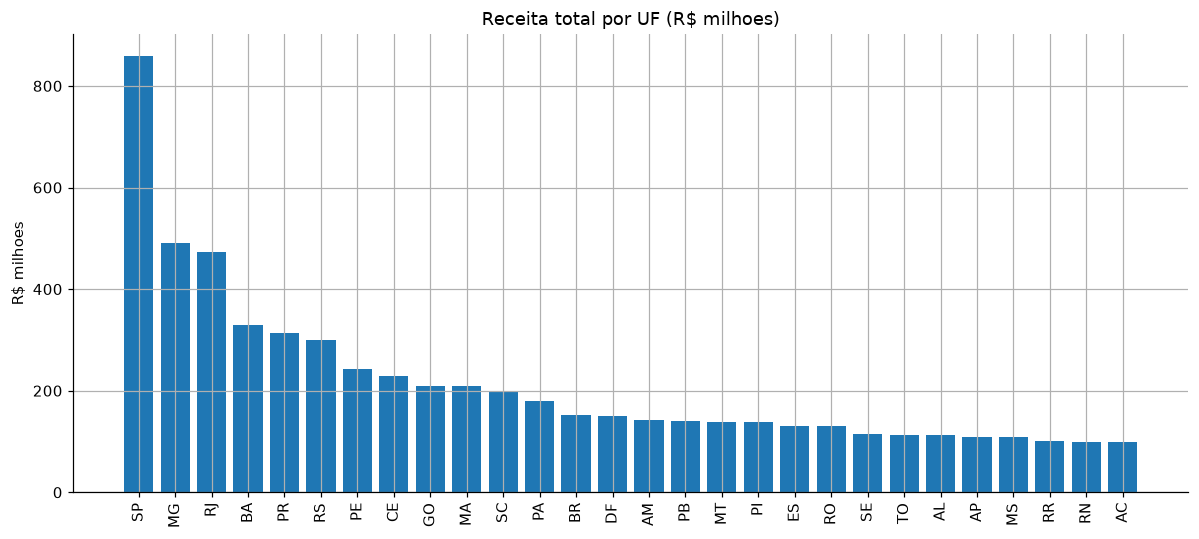

SG_UF,receita,n,receita_mi
cat,f64,u32,f64
"""SP""",8.5895e8,19567,858.945189
"""MG""",4.9027e8,13410,490.273492
"""RJ""",4.7243e8,13326,472.429074
"""BA""",3.2953e8,5562,329.525142
"""PR""",3.1284e8,7289,312.835217
"""RS""",2.9949e8,10556,299.487352
"""PE""",2.4196e8,4699,241.95815
"""CE""",2.2938e8,3530,229.383944
"""GO""",2.0933e8,5118,209.330276


In [11]:
por_uf = (
    rec.group_by("SG_UF")
    .agg(pl.col("VR_RECEITA").sum().alias("receita"), pl.len().alias("n"))
    .sort("receita", descending=True)
)
plt.figure()
plt.bar(por_uf["SG_UF"].to_list(), (por_uf["receita"] / 1e6).to_numpy())
plt.title("Receita total por UF (R$ milhoes)")
plt.ylabel("R$ milhoes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
por_uf.head(10).with_columns((pl.col("receita") / 1e6).alias("receita_mi"))

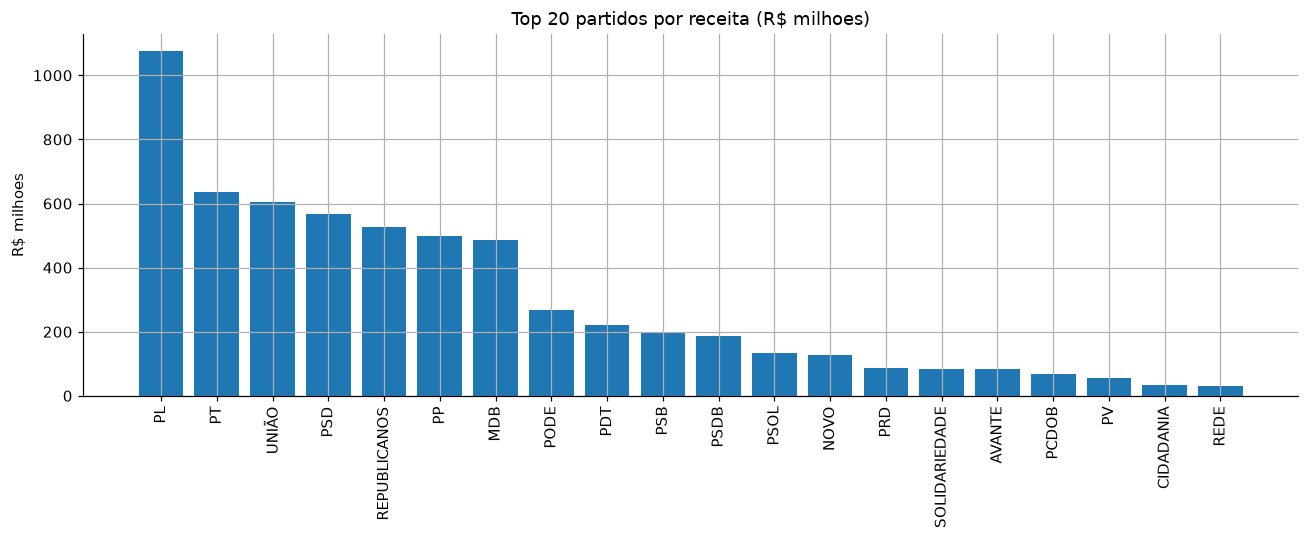

SG_PARTIDO,receita,n,candidatos,receita_mi
str,f64,u32,u32,f64
"""PL""",1.0747e9,12381,1530,1074.747658
"""PT""",6.3661e8,17142,1013,636.605609
"""UNIÃO""",6.0445e8,8487,809,604.450833
"""PSD""",5.6796e8,11175,1056,567.960113
"""REPUBLICANOS""",5.2675e8,9134,1219,526.750911
"""PP""",4.9926e8,4646,667,499.263472
"""MDB""",4.8541e8,9717,1336,485.409265
"""PODE""",2.6763e8,7708,1181,267.633817
…,…,…,…,…


In [12]:
por_partido = (
    rec.group_by("SG_PARTIDO")
    .agg(
        pl.col("VR_RECEITA").sum().alias("receita"),
        pl.len().alias("n"),
        pl.col("SQ_CANDIDATO").n_unique().alias("candidatos"),
    )
    .sort("receita", descending=True)
)
top_partido = por_partido.head(20)
plt.figure(figsize=(12, 5))
plt.bar(top_partido["SG_PARTIDO"].to_list(), (top_partido["receita"] / 1e6).to_numpy())
plt.title("Top 20 partidos por receita (R$ milhoes)")
plt.ylabel("R$ milhoes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
top_partido.with_columns((pl.col("receita") / 1e6).alias("receita_mi"))

In [13]:
fonte = (
    rec.group_by(["CD_FONTE_RECEITA", "DS_FONTE_RECEITA"])
    .agg(pl.col("VR_RECEITA").sum().alias("receita"), pl.len().alias("n"))
    .sort("receita", descending=True)
    .with_columns(
        (100 * pl.col("receita") / pl.col("receita").sum()).round(1).alias("pct"),
        (pl.col("receita") / 1e6).alias("receita_mi"),
    )
)
fonte

CD_FONTE_RECEITA,DS_FONTE_RECEITA,receita,n,pct,receita_mi
str,cat,f64,u32,f64,f64
"""2""","""FUNDO ESPECIAL""",4.8241e9,33773,80.2,4824.122342
"""1""","""OUTROS RECURSOS""",7.2105e8,88408,12.0,721.052528
"""0""","""FUNDO PARTIDARIO""",4.6728e8,11356,7.8,467.279696
null,null,0.0,2703,0.0,0.0


In [14]:
print("--- Natureza da receita ---")
display(
    rec.group_by("DS_NATUREZA_RECEITA")
    .agg(pl.col("VR_RECEITA").sum().alias("sum"), pl.len().alias("size"))
    .sort("sum", descending=True)
)

print("--- Especie da receita ---")
esp = (
    rec.group_by("DS_ESPECIE_RECEITA")
    .agg(pl.col("VR_RECEITA").sum().alias("sum"), pl.len().alias("size"))
    .sort("sum", descending=True)
)
display(esp.with_columns((pl.col("sum") / 1e6).alias("sum_mi")))

--- Natureza da receita ---


DS_NATUREZA_RECEITA,sum,size
cat,f64,u32
"""FINANCEIRO""",5.8464e9,84890
"""ESTIMÁVEL""",1.6608e8,51350


--- Especie da receita ---


DS_ESPECIE_RECEITA,sum,size,sum_mi
cat,f64,u32,f64
"""PIX""",3.9664e9,66759,3966.355524
"""Transferência eletrônica""",1.8552e9,14812,1855.199482
"""Estimado""",1.6608e8,51350,166.081635
"""Em espécie""",1.3503e7,176,13.502903
"""Cheque""",6.17239e6,77,6.17239
"""Depósito em espécie""",4.9682e6,260,4.968152
"""Não informado""",150056.62,54,0.150057
"""--""",14422.5,46,0.014423
"""Cartão de crédito""",8000.0,1,0.008


In [15]:
top_origem = (
    rec.group_by("DS_ORIGEM_RECEITA")
    .agg(pl.col("VR_RECEITA").sum().alias("sum"), pl.len().alias("size"))
    .sort("sum", descending=True)
    .head(15)
)
top_origem.with_columns((pl.col("sum") / 1e6).alias("sum_mi"))

DS_ORIGEM_RECEITA,sum,size,sum_mi
cat,f64,u32,f64
"""Recursos de partido político""",5.3406e9,46073,5340.635691
"""Recursos de pessoas físicas""",4.5100e8,66907,451.003425
"""Recursos próprios""",1.1053e8,8845,110.533911
"""Recursos de outros candidatos""",9.2214e7,9412,92.213724
"""Recursos de Financiamento Coletivo""",1.5235e7,1865,15.234872
"""Doações pela Internet""",1.4746e6,293,1.474575
"""Recursos de origens não identificadas""",1.3439e6,96,1.343945
"""Fundo Especial de Financiamento de Campanha""",14146.02,27,0.014146
"""Fundo Partidário""",275.6,3,0.000276


In [16]:
doadores = (
    rec.drop_nulls("NR_CPF_CNPJ_DOADOR")
    .group_by(["NR_CPF_CNPJ_DOADOR", "NM_DOADOR"])
    .agg(
        pl.col("VR_RECEITA").sum().alias("total"),
        pl.len().alias("doacoes"),
        pl.col("SQ_CANDIDATO").n_unique().alias("candidatos"),
    )
    .sort("total", descending=True)
    .head(20)
)
doadores.with_columns((pl.col("total") / 1e6).alias("total_mi"))

NR_CPF_CNPJ_DOADOR,NM_DOADOR,total,doacoes,candidatos,total_mi
str,str,f64,u32,u32,f64
"""08517423000195""","""Direção Nacional - PL""",9.4326e8,1904,1407,943.260553
"""00676262000170""","""Direção Nacional - PT""",5.5088e8,2081,960,550.88419
"""44551496000167""","""Direção Nacional - UNIÃO""",5.2041e8,1297,704,520.408624
"""00887169000105""","""Direção Nacional - PP""",4.7253e8,1171,640,472.528796
"""13629827000100""","""Direção Nacional - PSD""",4.4908e8,1080,790,449.084221
"""00676213000138""","""Direção Nacional - MDB""",3.9925e8,1326,1021,399.254721
"""07665132000181""","""Direção Nacional - REPUBLICANOS""",3.5739e8,1373,934,357.385179
"""01248362000169""","""Direção Nacional - PODE""",2.2702e8,1172,827,227.021027
…,…,…,…,…,…


In [17]:
rec_tipo = rec.with_columns(
    pl.when(pl.col("NR_CPF_CNPJ_DOADOR").str.len_chars() == 11)
    .then(pl.lit("PF"))
    .when(pl.col("NR_CPF_CNPJ_DOADOR").str.len_chars() == 14)
    .then(pl.lit("PJ"))
    .otherwise(pl.lit("sem documento"))
    .alias("TIPO_DOADOR")
)
resumo_tipo = (
    rec_tipo.group_by("TIPO_DOADOR")
    .agg(
        pl.col("VR_RECEITA").sum().alias("receita"),
        pl.len().alias("n"),
        pl.col("NR_CPF_CNPJ_DOADOR").n_unique().alias("doadores"),
    )
    .sort("receita", descending=True)
    .with_columns(
        (100 * pl.col("receita") / pl.col("receita").sum()).round(1).alias("pct"),
        (pl.col("receita") / 1e6).alias("receita_mi"),
    )
)
resumo_tipo

TIPO_DOADOR,receita,n,doadores,pct,receita_mi
str,f64,u32,u32,f64,f64
"""PJ""",5.4493e9,57442,1445,90.6,5449.325006
"""PF""",5.6288e8,76033,59743,9.4,562.882323
"""sem documento""",247237.2,2765,1,0.0,0.2472372


In [18]:
top_cnae = (
    rec.drop_nulls("DS_CNAE_DOADOR")
    .group_by("DS_CNAE_DOADOR")
    .agg(pl.col("VR_RECEITA").sum().alias("sum"), pl.len().alias("size"))
    .sort("sum", descending=True)
    .head(15)
)
top_cnae.with_columns((pl.col("sum") / 1e6).alias("sum_mi"))

DS_CNAE_DOADOR,sum,size,sum_mi
str,f64,u32,f64
"""Atividades de organizações políticas""",5.4311e9,54386,5431.131914
"""Atividades profissionais, científicas e técnicas não especif…",1.4032e7,1730,14.032128
"""Atividades de associações de defesa de direitos sociais""",2.9601e6,1192,2.9600997
"""Atividades de consultoria em gestão empresarial""",510472.08,46,0.510472
"""Tratamento de dados, provedores de serviços de aplicação e s…",366115.28,63,0.366115
"""Suporte técnico, manutenção e outros serviços em tecnologia …",282718.35,5,0.282718
"""Consultoria em tecnologia da informação""",38498.0,17,0.038498
"""Atividades de ensino não especificadas anteriormente""",3060.0,3,0.00306


shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ value         │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 133536.0      │
│ null_count ┆ 0.0           │
│ mean       ┆ 45024.971287  │
│ std        ┆ 259561.461817 │
│ min        ┆ 0.01          │
│ 25%        ┆ 500.0         │
│ 50%        ┆ 2150.0        │
│ 75%        ┆ 10000.0       │
│ max        ┆ 3.5e7         │
└────────────┴───────────────┘


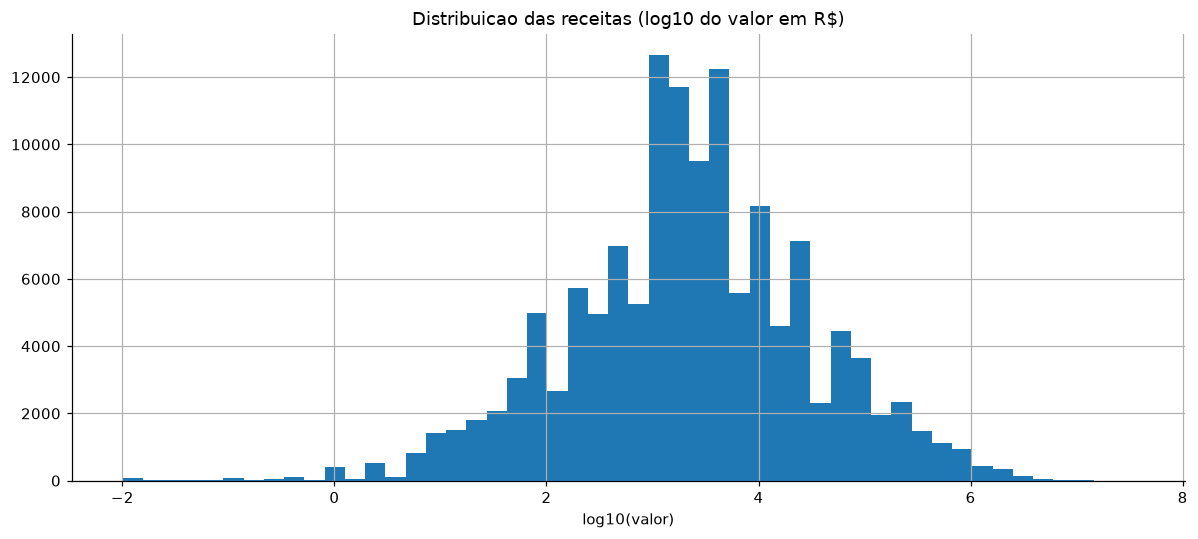

In [19]:
vals = rec.filter(pl.col("VR_RECEITA") > 0)["VR_RECEITA"]
print(vals.describe())

plt.figure()
plt.hist(np.log10(vals.to_numpy()), bins=50)
plt.title("Distribuicao das receitas (log10 do valor em R$)")
plt.xlabel("log10(valor)")
plt.tight_layout()
plt.show()

## 5. Despesas

In [20]:
con = tabelas["despesas_contratadas"]
pag = tabelas["despesas_pagas"]

print(f"Total contratado (BRASIL): R$ {con['VR_DESPESA_CONTRATADA'].sum():,.2f}")
print(f"Total pago       (BRASIL): R$ {pag['VR_PAGTO_DESPESA'].sum():,.2f}")
print("Obs: despesas_pagas nao traz DS_CARGO/SG_PARTIDO - comparacao por cargo exige join.")

Total contratado (BRASIL): R$ 3,859,427,438.43
Total pago       (BRASIL): R$ 2,350,272,389.13
Obs: despesas_pagas nao traz DS_CARGO/SG_PARTIDO - comparacao por cargo exige join.


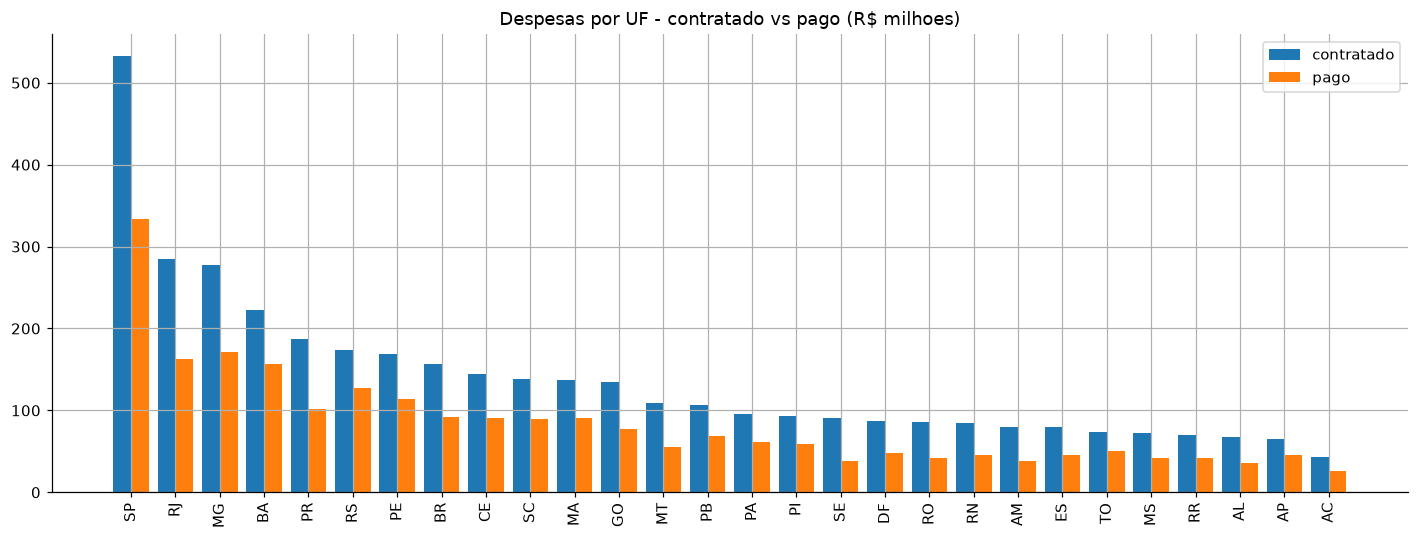

SG_UF,contratado,pago,contratado_mi,pago_mi
cat,f64,f64,f64,f64
"""SP""",5.3268e8,3.3388e8,532.681578,333.876162
"""RJ""",2.8511e8,1.6245e8,285.110217,162.447484
"""MG""",2.7693e8,1.7168e8,276.926077,171.678979
"""BA""",2.2241e8,1.5723e8,222.405353,157.233211
"""PR""",1.8728e8,1.0217e8,187.277263,102.17309
"""RS""",1.7376e8,1.2736e8,173.759713,127.355633
"""PE""",1.6858e8,1.1418e8,168.57608,114.175305
"""BR""",1.5708e8,9.1469e7,157.082483,91.468818
…,…,…,…,…


In [21]:
c_uf = con.group_by("SG_UF").agg(pl.col("VR_DESPESA_CONTRATADA").sum().alias("contratado"))
p_uf = pag.group_by("SG_UF").agg(pl.col("VR_PAGTO_DESPESA").sum().alias("pago"))
comp_uf = (
    c_uf.join(p_uf, on="SG_UF", how="full", coalesce=True)
    .fill_null(0)
    .sort("contratado", descending=True)
)
x = np.arange(comp_uf.height)
w = 0.4
plt.figure(figsize=(13, 5))
plt.bar(x - w / 2, (comp_uf["contratado"] / 1e6).to_numpy(), w, label="contratado")
plt.bar(x + w / 2, (comp_uf["pago"] / 1e6).to_numpy(), w, label="pago")
plt.xticks(x, comp_uf["SG_UF"].to_list(), rotation=90)
plt.legend()
plt.title("Despesas por UF - contratado vs pago (R$ milhoes)")
plt.tight_layout()
plt.show()
comp_uf.with_columns(
    (pl.col("contratado") / 1e6).alias("contratado_mi"),
    (pl.col("pago") / 1e6).alias("pago_mi"),
)

In [22]:
top_cat = (
    con.group_by("DS_ORIGEM_DESPESA")
    .agg(pl.col("VR_DESPESA_CONTRATADA").sum().alias("sum"), pl.len().alias("size"))
    .sort("sum", descending=True)
    .head(15)
)
top_cat.with_columns((pl.col("sum") / 1e6).alias("sum_mi"))

DS_ORIGEM_DESPESA,sum,size,sum_mi
cat,f64,u32,f64
"""Publicidade por materiais impressos""",6.7616e8,122570,676.158118
"""Serviços prestados por terceiros""",6.0898e8,32293,608.977485
"""Atividades de militância e mobilização de rua""",4.8062e8,247206,480.622377
"""Despesas com pessoal""",4.1421e8,131866,414.212032
"""Despesa com Impulsionamento de Conteúdos""",2.8491e8,22952,284.911798
"""Serviços advocatícios""",2.2297e8,6551,222.970644
"""Publicidade por adesivos""",2.0625e8,46090,206.25477
"""Produção de programas de rádio, televisão ou vídeo""",2.0431e8,3553,204.312335
"""Cessão ou locação de veículos""",1.5020e8,19380,150.198688


In [23]:
top_cat_pg = (
    pag.group_by("DS_ORIGEM_DESPESA")
    .agg(pl.col("VR_PAGTO_DESPESA").sum().alias("sum"), pl.len().alias("size"))
    .sort("sum", descending=True)
    .head(15)
)
top_cat_pg.with_columns((pl.col("sum") / 1e6).alias("sum_mi"))

DS_ORIGEM_DESPESA,sum,size,sum_mi
cat,f64,u32,f64
"""Publicidade por materiais impressos""",5.1368e8,33693,513.684028
"""Serviços prestados por terceiros""",3.5833e8,25686,358.326123
"""Despesa com Impulsionamento de Conteúdos""",2.7367e8,22629,273.67235
"""Despesas com pessoal""",1.7056e8,82152,170.56024
"""Atividades de militância e mobilização de rua""",1.6696e8,148791,166.961576
"""Publicidade por adesivos""",1.5092e8,10306,150.917462
"""Produção de programas de rádio, televisão ou vídeo""",1.3774e8,3095,137.73808
"""Serviços advocatícios""",1.1002e8,3801,110.017114
"""Cessão ou locação de veículos""",7.2607e7,9439,72.607173


In [24]:
fornecedores = (
    con.drop_nulls("NR_CPF_CNPJ_FORNECEDOR")
    .group_by(["NR_CPF_CNPJ_FORNECEDOR", "NM_FORNECEDOR"])
    .agg(
        pl.col("VR_DESPESA_CONTRATADA").sum().alias("total"),
        pl.len().alias("contratos"),
        pl.col("SQ_CANDIDATO").n_unique().alias("candidatos"),
    )
    .sort("total", descending=True)
    .head(20)
)
fornecedores.with_columns((pl.col("total") / 1e6).alias("total_mi"))

NR_CPF_CNPJ_FORNECEDOR,NM_FORNECEDOR,total,contratos,candidatos,total_mi
str,str,f64,u32,u32,f64
"""13347016000117""","""FACEBOOK SERVICOS ONLINE DO BRASIL LTDA.""",1.9069e8,17330,5414,190.688568
"""25021356000132""","""DLOCAL BRASIL INSTITUICAO DE PAGAMENTO S.A.""",7.4274e7,4481,1774,74.2736
"""63984717000135""","""DELTA3 COMUNICACAO E PROJETOS LTDA""",3.1e7,1,1,31.0
"""55554460000153""","""EPOS BRASIL ESTRATEGIA, COMUNICACAO E TECNOLOGIA LTDA""",2e7,2,1,20.0
"""09383641000147""","""F.A.R.O PROPAGANDA E PUBLICIDADE LTDA""",1.34e7,3,3,13.4
"""24080493000185""","""EBANX PAGAMENTOS LTDA""",9.0547e6,443,194,9.054676
"""28573576000167""","""URISSANE COMUNICACAO LTDA""",8.708e6,4,4,8.708
"""00758606000190""","""MXM GRAFICA E EMBALAGENS LTDA""",8.60748e6,1303,28,8.60748
…,…,…,…,…,…


In [25]:
doc = (
    con.group_by("DS_TIPO_DOCUMENTO")
    .agg(pl.col("VR_DESPESA_CONTRATADA").sum().alias("sum"), pl.len().alias("size"))
    .sort("sum", descending=True)
)
doc.with_columns((pl.col("sum") / 1e6).alias("sum_mi"))

DS_TIPO_DOCUMENTO,sum,size,sum_mi
cat,f64,u32,f64
"""Outro""",2.1339e9,443504,2133.891392
"""Nota Fiscal""",1.4702e9,249468,1470.215688
"""Recibo""",1.0560e8,28025,105.598591
"""Fatura""",6.2631e7,6885,62.630613
null,5.5649e7,55304,55.649121
"""Cupom Fiscal""",1.0603e7,9482,10.603463
"""RPA - Recibo de Pagamento Autônomo""",1.0433e7,3635,10.433076
"""Duplicata""",1.0405e7,1082,10.405494


### 5.1 Divida de campanha (formula do leiame)

`F = (contratado elegivel) - (pago elegivel)`, excluindo as contas DRD de transferencia/devolucao listadas no leiame. Ressalva: a formula oficial usa apenas a entrega `Final`; aqui nao existe `Final`, entao o numero e uma estimativa.

In [26]:
EXCL_CONTRATADAS = ["20320000", "30020000", "20330000", "20340000", "20370000", "20380000", "20390000"]
EXCL_PAGAS = ["20330000", "20340000", "20370000", "20380000", "20390000"]

n_exc_c = con.filter(pl.col("CD_ORIGEM_DESPESA").is_in(EXCL_CONTRATADAS)).height
n_exc_p = pag.filter(pl.col("CD_ORIGEM_DESPESA").is_in(EXCL_PAGAS)).height
print(f"Linhas excluidas por DRD - contratadas: {n_exc_c:,} | pagas: {n_exc_p:,}")
print("(neste snapshot os codigos de exclusao nao aparecem, entao nada e removido)\n")

soma_c = con.filter(~pl.col("CD_ORIGEM_DESPESA").is_in(EXCL_CONTRATADAS))["VR_DESPESA_CONTRATADA"].sum()
soma_p = pag.filter(~pl.col("CD_ORIGEM_DESPESA").is_in(EXCL_PAGAS))["VR_PAGTO_DESPESA"].sum()

print(f"Contratado elegivel : R$ {soma_c:,.2f}")
print(f"Pago elegivel       : R$ {soma_p:,.2f}")
print(f"Divida estimada (F) : R$ {soma_c - soma_p:,.2f}")

Linhas excluidas por DRD - contratadas: 0 | pagas: 0
(neste snapshot os codigos de exclusao nao aparecem, entao nada e removido)

Contratado elegivel : R$ 3,859,427,438.43
Pago elegivel       : R$ 2,350,272,389.13
Divida estimada (F) : R$ 1,509,155,049.30


## 6. Doadores originarios

In [27]:
doa = tabelas["receitas_doador_originario"]
print(f"Registros                     : {doa.height:,}")
print(f"Com doador originario nomeado : {doa['NM_DOADOR_ORIGINARIO'].drop_nulls().len():,}")
print(f"Valor total declarado         : R$ {doa['VR_RECEITA'].sum():,.2f}")
doa.group_by("TP_DOADOR_ORIGINARIO").len().sort("len", descending=True)

Registros                     : 258,441
Com doador originario nomeado : 241,501
Valor total declarado         : R$ 169,111,798.69


TP_DOADOR_ORIGINARIO,len
str,u32
"""F""",241501
null,16940


In [28]:
top_doa = (
    doa.drop_nulls("NM_DOADOR_ORIGINARIO")
    .group_by(["NM_DOADOR_ORIGINARIO", "TP_DOADOR_ORIGINARIO"])
    .agg(pl.col("VR_RECEITA").sum().alias("sum"), pl.len().alias("size"))
    .sort("sum", descending=True)
    .head(20)
)
top_doa.with_columns((pl.col("sum") / 1e6).alias("sum_mi"))

NM_DOADOR_ORIGINARIO,TP_DOADOR_ORIGINARIO,sum,size,sum_mi
str,str,f64,u32,f64
"""João de Lima Geo Filho""","""F""",6e6,24,6.0
"""LUIZ GUSTAVO TURCHETTO SANTOS""","""F""",5.58e6,25,5.58
"""JOSE FELIPE DINIZ""","""F""",3.9e6,13,3.9
"""JEFERSON DEGASPARI""","""F""",3.3848e6,55,3.384762
"""GUSTAVO JOSE MOURA DUBEUX""","""F""",3.2635e6,16,3.263509
"""BERNARDO IMPELLIZIERI SA MATTOS""","""F""",3.235e6,27,3.235
"""CARLOS SEABRA SUAREZ""","""F""",2.305e6,31,2.305
"""JOSE SERIPIERI FILHO""","""F""",1.92959e6,23,1.92959
…,…,…,…,…


## 7. Cortes transversais

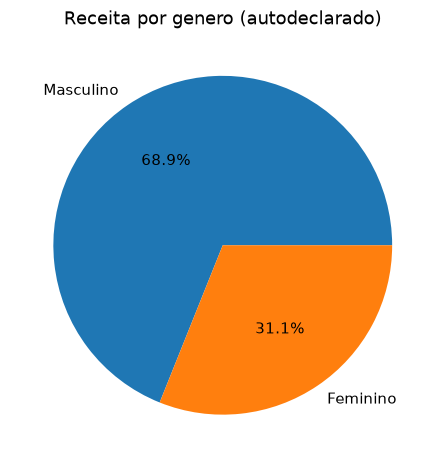

DS_GENERO,receita,candidatos,receita_media,pct_receita,receita_mi
cat,f64,u32,f64,f64,f64
"""Masculino""",4.1443e9,12317,42406.811891,68.9,4144.290506
"""Feminino""",1.8682e9,6808,48507.362713,31.1,1868.16406


In [29]:
genero = (
    rec.group_by("DS_GENERO")
    .agg(
        pl.col("VR_RECEITA").sum().alias("receita"),
        pl.col("SQ_CANDIDATO").n_unique().alias("candidatos"),
        pl.col("VR_RECEITA").mean().alias("receita_media"),
    )
    .sort("receita", descending=True)
    .with_columns((100 * pl.col("receita") / pl.col("receita").sum()).round(1).alias("pct_receita"))
)
plt.figure()
plt.pie(
    genero["receita"].to_numpy(),
    labels=genero["DS_GENERO"].to_list(),
    autopct="%.1f%%",
)
plt.title("Receita por genero (autodeclarado)")
plt.show()
genero.with_columns((pl.col("receita") / 1e6).alias("receita_mi"))

In [30]:
cor_raca = (
    rec.group_by("DS_COR_RACA")
    .agg(
        pl.col("VR_RECEITA").sum().alias("receita"),
        pl.col("SQ_CANDIDATO").n_unique().alias("candidatos"),
        pl.col("VR_RECEITA").mean().alias("receita_media"),
    )
    .sort("receita", descending=True)
    .with_columns((100 * pl.col("receita") / pl.col("receita").sum()).round(1).alias("pct_receita"))
)
cor_raca.with_columns((pl.col("receita") / 1e6).alias("receita_mi"))

DS_COR_RACA,receita,candidatos,receita_media,pct_receita,receita_mi
cat,f64,u32,f64,f64,f64
"""Branca""",3.9857e9,9676,45155.729145,66.3,3985.670433
"""Parda""",1.4914e9,6601,44544.651779,24.8,1491.444031
"""Preta""",4.6776e8,2566,35576.72267,7.8,467.76275
"""Indígena""",4.7992e7,185,61214.038584,0.8,47.991806
"""Amarela""",1.9586e7,97,34911.846916,0.3,19.585546


Candidatos com receita declarada: 19,125

Top  1% dos candidatos (  191) concentram  18.5% da receita
Top  5% dos candidatos (  956) concentram  48.8% da receita
Top 10% dos candidatos (1,912) concentram  65.8% da receita
Top 20% dos candidatos (3,825) concentram  82.9% da receita


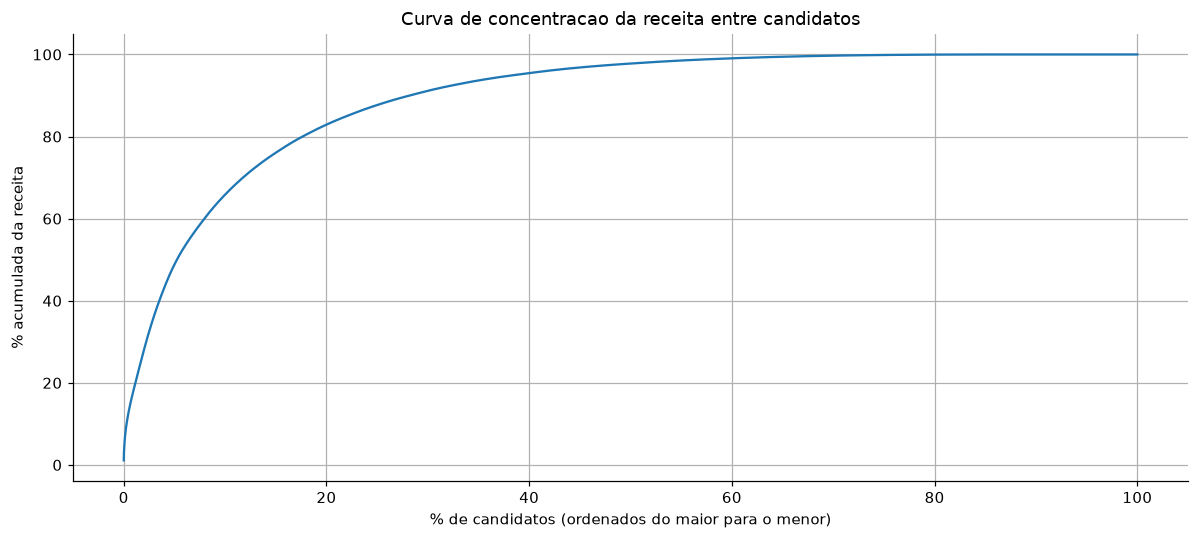

In [31]:
por_cand = (
    rec.group_by("SQ_CANDIDATO")
    .agg(pl.col("VR_RECEITA").sum().alias("receita"))
    .sort("receita", descending=True)
)
total = por_cand["receita"].sum()
print(f"Candidatos com receita declarada: {por_cand.height:,}\n")
for p in [0.01, 0.05, 0.10, 0.20]:
    n = max(1, int(por_cand.height * p))
    share = por_cand.head(n)["receita"].sum() / total
    print(f"Top {int(p * 100):>2}% dos candidatos ({n:>5,}) concentram {100 * share:5.1f}% da receita")

cum = (por_cand["receita"].cum_sum() / total).to_numpy()
eixo_x = np.arange(1, por_cand.height + 1) / por_cand.height
plt.figure()
plt.plot(eixo_x * 100, cum * 100)
plt.title("Curva de concentracao da receita entre candidatos")
plt.xlabel("% de candidatos (ordenados do maior para o menor)")
plt.ylabel("% acumulada da receita")
plt.tight_layout()
plt.show()

## 8. Ressalvas e proximos passos

- **Dados preliminares**: snapshot de 27/09/2026, apenas `Parcial` e `Relatorio Financeiro`; nao ha entrega `Final`, entao receitas, despesas e a divida estimada sao valores parciais.
- **BRASIL x UF**: usar somente os arquivos consolidados; somar as duas familias duplicaria os registros.
- **Chaves**: `SQ_RECEITA` e `SQ_DESPESA` nao sao unicas; nao deduplicar sem analisar o contexto.
- **Divergencia de leiame**: coluna real `AA_ELEICAO`; `despesas_contratadas` nao traz `CD_FONTE_DESPESA` apesar do leiame.
- **Polars**: leitura eager com `read_csv` (o `scan_csv` lazy nao suporta Latin-1); as quatro tabelas cabem em ~0,4 GB. Para volumes maiores, transcrever os CSV para UTF-8/Parquet uma vez permitiria `scan_parquet` + streaming.
- **Possiveis desdobramentos**: comparar o recorte por partido x cargo; ligar pagamentos a contratadas via `(SQ_PRESTADOR_CONTAS, SQ_DESPESA)`; ranking de fornecedores por partido; evolucao entre entregas quando houver `Final`.